In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Dataset

df = pd.read_csv(r"C:\Users\HP\Desktop\NEW PROJECTS CLASS\Data Science Projects\Restaurant sales Analysis\data.csv")

print(df.head())
print(df.info())

   Order_ID        Date   Time      Item   Category  Quantity  Price
0      1001  2025-01-01  12:15    Burger  Fast Food         2    150
1      1002  2025-01-01  13:00     Pizza    Italian         1    300
2      1003  2025-01-01  18:30     Pasta    Italian         2    250
3      1004  2025-01-01  19:15      Coke   Beverage         3     50
4      1005  2025-01-02  11:45  Sandwich  Fast Food         1    120
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  50 non-null     int64 
 1   Date      50 non-null     object
 2   Time      50 non-null     object
 3   Item      50 non-null     object
 4   Category  50 non-null     object
 5   Quantity  50 non-null     int64 
 6   Price     50 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 2.9+ KB
None


In [4]:
# Check Missing Values

print(df.isnull().sum())

Order_ID    0
Date        0
Time        0
Item        0
Category    0
Quantity    0
Price       0
dtype: int64


In [5]:
# Remove Duplicates

df.drop_duplicates(inplace=True)

In [6]:
# Convert Date Format

df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# Create Revenue Column

df['Revenue'] = df['Quantity'] * df['Price']

In [8]:
#  Exploratory Data Analysis (EDA)

# Total Revenue

total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 15080


In [9]:
# Top Selling Items

top_items = df.groupby('Item')['Quantity'].sum()

top_items.sort_values(ascending=False).head(10)

Item
Burger      18
Pizza       17
Pasta       15
Coke        13
Fries       12
Coffee       8
Tea          8
Sandwich     7
Name: Quantity, dtype: int64

In [10]:
# Revenue by Category

category_sales = df.groupby('Category')['Revenue'].sum()

print(category_sales)

Category
Beverage     1610
Fast Food    4620
Italian      8850
Name: Revenue, dtype: int64


In [11]:
# Daily Sales

daily_sales = df.groupby('Date')['Revenue'].sum()

print(daily_sales)

Date
2025-01-01    1250
2025-01-02    1480
2025-01-03     660
2025-01-04    1230
2025-01-05    1160
2025-01-06    1230
2025-01-07    1170
2025-01-08     830
2025-01-09    1010
2025-01-10    1490
2025-01-11    1110
2025-01-12    1330
2025-01-13    1130
Name: Revenue, dtype: int64


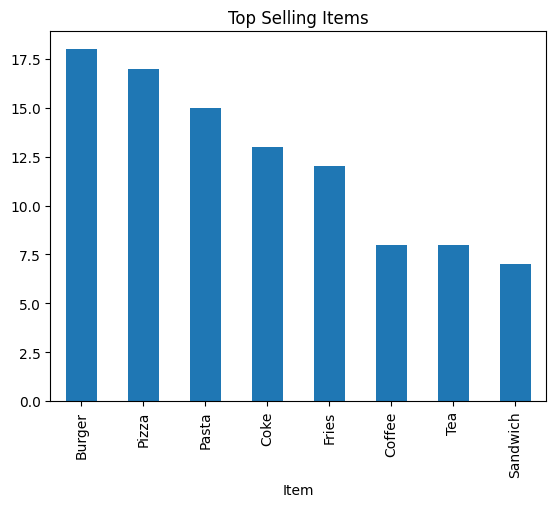

In [12]:
# Data Visualization

# Top Selling Products

top_items.sort_values(ascending=False).head(10).plot(
    kind='bar'
)

plt.title("Top Selling Items")
plt.show()

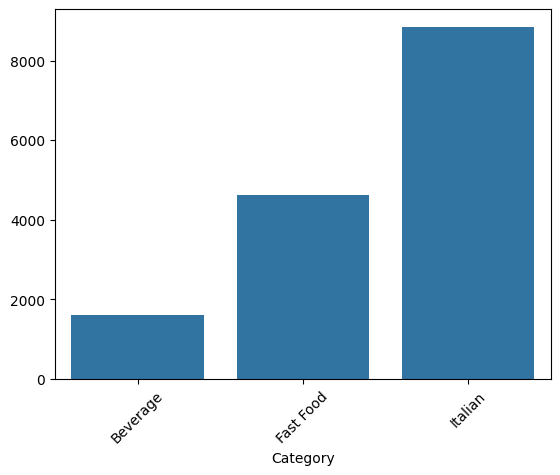

In [13]:
# Revenue by Category

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.xticks(rotation=45)
plt.show()

In [14]:
# Time Analysis

# Extract Day and Hour

df['Hour'] = pd.to_datetime(df['Time']).dt.hour
df['Day'] = df['Date'].dt.day_name()

C:\Users\HP\AppData\Local\Temp\ipykernel_21732\3745028712.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


In [15]:
# Peak Hours

peak_hours = df.groupby('Hour')['Revenue'].sum()

print(peak_hours)

Hour
10     160
11     840
12    2730
13    2100
14     570
15     600
17     200
18    2450
19    1580
20    3250
21     600
Name: Revenue, dtype: int64


In [16]:
# Peak Days

peak_days = df.groupby('Day')['Revenue'].sum()

print(peak_days)

Day
Friday       2150
Monday       2360
Saturday     2340
Sunday       2490
Thursday     2490
Tuesday      1170
Wednesday    2080
Name: Revenue, dtype: int64


In [17]:
# Customer Insights

# Most Ordered Categories

category_orders = df.groupby(
    'Category'
)['Quantity'].sum()

print(category_orders)

Category
Beverage     29
Fast Food    37
Italian      32
Name: Quantity, dtype: int64


In [18]:
# Average Order Value

avg_order_value = df.groupby(
    'Order_ID'
)['Revenue'].sum().mean()

print(avg_order_value)

301.6


In [20]:
# Profit Analysis

# If Cost column exists:

df['Profit'] = (
    df['Revenue'] - df['Price']
)

profit_category = df.groupby(
    'Category'
)['Profit'].sum()

print(profit_category)

Category
Beverage      800
Fast Food    2220
Italian      4150
Name: Profit, dtype: int64
